<a href="https://colab.research.google.com/github/tanvirs08/Fruit-Image-Classification-Using-Hand-crafted-Features-and-CNN/blob/main/project_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle opencv-python scikit-image -q

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p /content/small_fruit
!kaggle datasets download -d mbkinaci/fruit-images-for-object-detection -p /content/small_fruit --unzip

print("Dataset downloaded successfully!")

Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection
License(s): CC0-1.0
100% 28.4M/28.4M [00:00<00:00, 216MB/s]

Dataset downloaded successfully!


In [ ]:
import os
import cv2
import random
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 96
RAW_DATASET = Path("/content/small_fruit")
CLASS_DATASET = Path("/content/fruit_classification_dataset")

CLASSES = ["apple", "banana", "orange"]

In [ ]:
def clean_class_name(name):
    name = name.lower().strip()
    if "apple" in name:
        return "apple"
    elif "banana" in name:
        return "banana"
    elif "orange" in name:
        return "orange"
    return None


def find_image_file(xml_file, image_filename):
    possible_paths = [
        xml_file.parent / image_filename,
        xml_file.parent / image_filename.replace(".jpg", ".png"),
        xml_file.parent / image_filename.replace(".png", ".jpg"),
        xml_file.parent / image_filename.replace(".jpeg", ".jpg"),
    ]

    for p in possible_paths:
        if p.exists():
            return p

    # fallback: search by stem
    stem = Path(image_filename).stem
    for ext in [".jpg", ".jpeg", ".png"]:
        matches = list(RAW_DATASET.rglob(stem + ext))
        if matches:
            return matches[0]

    return None


def create_classification_dataset():
    if CLASS_DATASET.exists():
        shutil.rmtree(CLASS_DATASET)

    for cls in CLASSES:
        (CLASS_DATASET / cls).mkdir(parents=True, exist_ok=True)

    xml_files = list(RAW_DATASET.rglob("*.xml"))
    print("Total XML files found:", len(xml_files))

    saved_count = {cls: 0 for cls in CLASSES}

    for xml_file in xml_files:
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()

            filename_tag = root.find("filename")
            if filename_tag is None:
                continue

            image_filename = filename_tag.text
            image_path = find_image_file(xml_file, image_filename)

            if image_path is None:
                continue

            image = cv2.imread(str(image_path))
            if image is None:
                continue

            for obj in root.findall("object"):
                name_tag = obj.find("name")
                box_tag = obj.find("bndbox")

                if name_tag is None or box_tag is None:
                    continue

                cls = clean_class_name(name_tag.text)
                if cls not in CLASSES:
                    continue

                xmin = int(float(box_tag.find("xmin").text))
                ymin = int(float(box_tag.find("ymin").text))
                xmax = int(float(box_tag.find("xmax").text))
                ymax = int(float(box_tag.find("ymax").text))

                h, w = image.shape[:2]

                xmin = max(0, xmin)
                ymin = max(0, ymin)
                xmax = min(w, xmax)
                ymax = min(h, ymax)

                crop = image[ymin:ymax, xmin:xmax]

                if crop.size == 0:
                    continue

                crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))

                save_name = f"{cls}_{saved_count[cls]:04d}.jpg"
                save_path = CLASS_DATASET / cls / save_name

                cv2.imwrite(str(save_path), crop)
                saved_count[cls] += 1

        except Exception as e:
            print("Error:", xml_file, e)

    print("Classification dataset created!")
    for cls in CLASSES:
        print(cls, ":", saved_count[cls], "images")


create_classification_dataset()

Total XML files found: 300
Classification dataset created!
apple : 191 images
banana : 209 images
orange : 182 images


Total images: 582
Image shape: (582, 96, 96, 3)
Classes: [np.str_('apple'), np.str_('banana'), np.str_('orange')]


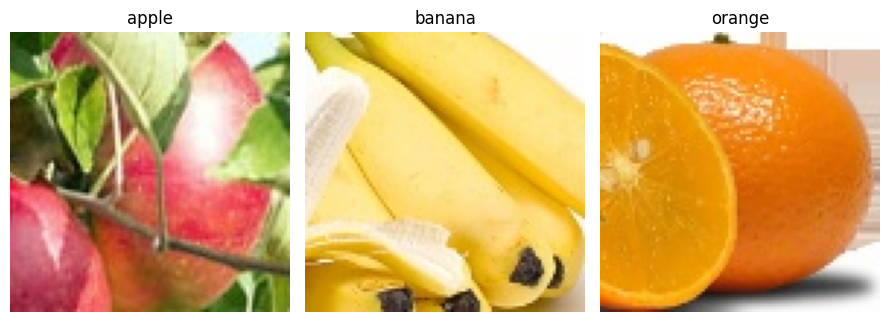

In [ ]:
def load_images(dataset_dir, img_size=IMG_SIZE):
    X = []
    y = []

    for cls in CLASSES:
        class_path = dataset_dir / cls

        for img_path in class_path.glob("*.*"):
            img = cv2.imread(str(img_path))

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))

            X.append(img)
            y.append(cls)

    return np.array(X), np.array(y)


X, y = load_images(CLASS_DATASET)

print("Total images:", len(X))
print("Image shape:", X.shape)
print("Classes:", sorted(set(y)))

plt.figure(figsize=(9, 4))

for i, cls in enumerate(CLASSES):
    idx = np.where(y == cls)[0][0]
    plt.subplot(1, 3, i + 1)
    plt.imshow(X[idx])
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def color_histogram(img):
    features = []

    for channel in range(3):
        hist, _ = np.histogram(
            img[:, :, channel],
            bins=16,
            range=(0, 256),
            density=True
        )
        features.extend(hist)

    return np.array(features)


def hog_feature(img):
    gray = rgb2gray(img)

    feature = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        feature_vector=True
    )

    return feature


def lbp_feature(img):
    gray = rgb2gray(img)

    lbp = local_binary_pattern(
        gray,
        P=8,
        R=1,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=10,
        range=(0, 10),
        density=True
    )

    return hist


def extract_handcrafted_features(images):
    feature_list = []

    for img in images:
        color = color_histogram(img)
        hog_f = hog_feature(img)
        lbp_f = lbp_feature(img)

        combined_feature = np.concatenate([color, hog_f, lbp_f])
        feature_list.append(combined_feature)

    return np.array(feature_list)


features = extract_handcrafted_features(X)

print("Hand-crafted feature shape:", features.shape)

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Hand-crafted feature shape: (582, 4414)


Method 1: Hand-crafted Feature + SVM Accuracy: 87.18 %

              precision    recall  f1-score   support

       apple       0.89      0.84      0.86        38
      banana       0.89      0.95      0.92        42
      orange       0.83      0.81      0.82        37

    accuracy                           0.87       117
   macro avg       0.87      0.87      0.87       117
weighted avg       0.87      0.87      0.87       117



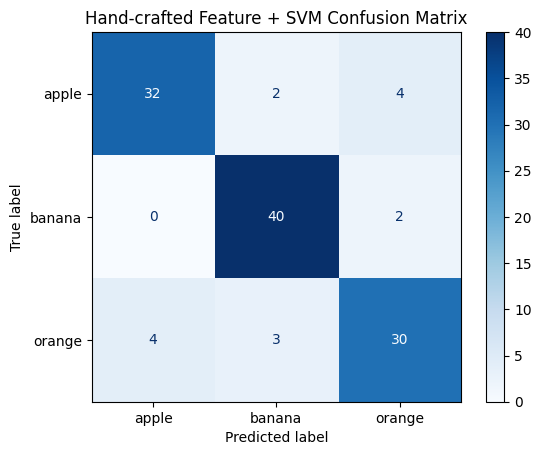

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    features,
    y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel="rbf", C=5, gamma="scale")
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("Method 1: Hand-crafted Feature + SVM Accuracy:", round(svm_accuracy * 100, 2), "%")
print()
print(classification_report(y_test, svm_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Hand-crafted Feature + SVM Confusion Matrix")
plt.show()

In [ ]:
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

print("Training images:", X_train_img.shape)
print("Testing images:", X_test_img.shape)

Training images: (465, 96, 96, 3)
Testing images: (117, 96, 96, 3)


In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(len(CLASSES), activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,163 (6.61 MB)

 Trainable params: 1,732,163 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = cnn_model.fit(
    X_train_img,
    y_train_img,
    validation_split=0.15,
    epochs=15,
    batch_size=16,
    verbose=1
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 288ms/step - accuracy: 0.6608 - loss: 0.7515 - val_accuracy: 0.7857 - val_loss: 0.5137
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 488ms/step - accuracy: 0.8608 - loss: 0.3609 - val_accuracy: 0.9714 - val_loss: 0.1185
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 478ms/step - accuracy: 0.9418 - loss: 0.2227 - val_accuracy: 0.9286 - val_loss: 0.1653
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 260ms/step - accuracy: 0.9544 - loss: 0.1431 - val_accuracy: 0.9429 - val_loss: 0.1087
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 252ms/step - accuracy: 0.9747 - loss: 0.1123 - val_accuracy: 0.9286 - val_loss: 0.1890
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 307ms/step - accuracy: 0.9620 - loss: 0.1299 - val_accuracy: 0.9571 - val_loss: 0.1631
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step - accuracy: 0.9797 - loss: 0.0883 - val_accuracy: 0.9429 - val_loss: 0.2142
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 305ms/step - accuracy: 0.9772 - loss: 0.0854 - val_accurac

Method 2: CNN Accuracy: 95.73 %
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step

              precision    recall  f1-score   support

       apple       0.97      0.95      0.96        38
      banana       0.95      0.95      0.95        42
      orange       0.95      0.97      0.96        37

    accuracy                           0.96       117
   macro avg       0.96      0.96      0.96       117
weighted avg       0.96      0.96      0.96       117



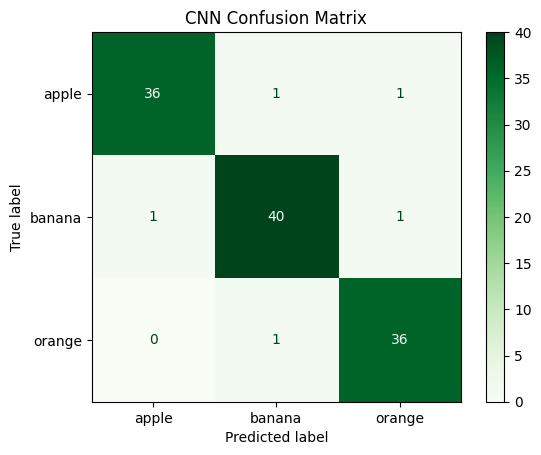

In [ ]:
loss, cnn_accuracy = cnn_model.evaluate(X_test_img, y_test_img, verbose=0)

print("Method 2: CNN Accuracy:", round(cnn_accuracy * 100, 2), "%")

cnn_prob = cnn_model.predict(X_test_img)
cnn_pred = np.argmax(cnn_prob, axis=1)

print()
print(classification_report(y_test_img, cnn_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test_img, cnn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Greens")
plt.title("CNN Confusion Matrix")
plt.show()

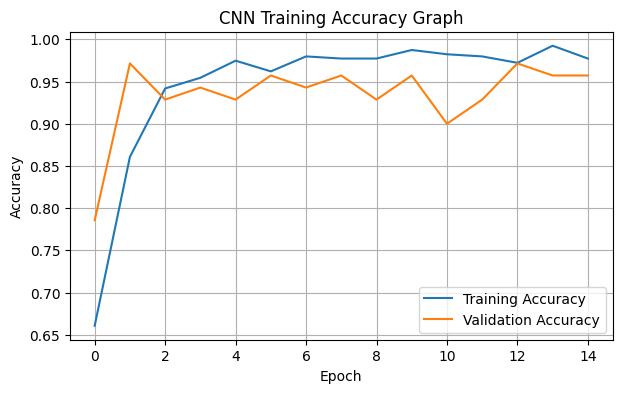

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training Accuracy Graph")
plt.legend()
plt.grid(True)
plt.show()

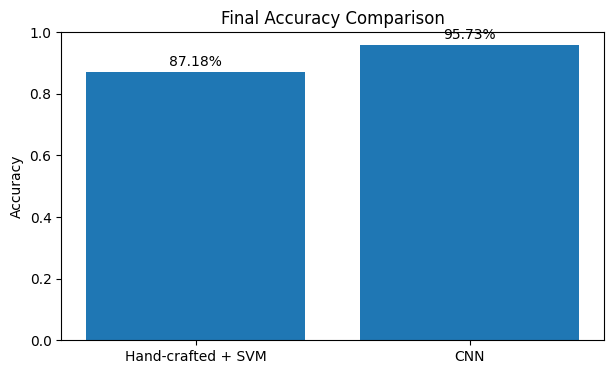

Final Result Comparison
-----------------------
Method 1: Hand-crafted Feature + SVM = 87.18 %
Method 2: Automated Feature + CNN    = 95.73 %


In [ ]:
methods = ["Hand-crafted + SVM", "CNN"]
accuracies = [svm_accuracy, cnn_accuracy]

plt.figure(figsize=(7, 4))
plt.bar(methods, accuracies)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Final Accuracy Comparison")

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, str(round(acc * 100, 2)) + "%", ha="center")

plt.show()

print("Final Result Comparison")
print("-----------------------")
print("Method 1: Hand-crafted Feature + SVM =", round(svm_accuracy * 100, 2), "%")
print("Method 2: Automated Feature + CNN    =", round(cnn_accuracy * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


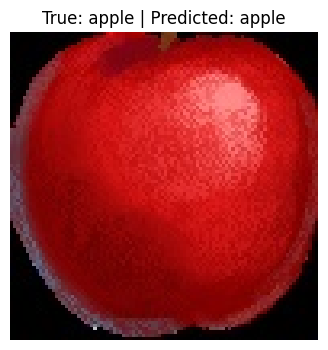

In [ ]:
def predict_random_image():
    random_index = random.randint(0, len(X_test_img) - 1)

    img = X_test_img[random_index]
    true_label = label_encoder.inverse_transform([y_test_img[random_index]])[0]

    input_img = np.expand_dims(img, axis=0)

    pred_prob = cnn_model.predict(input_img)
    pred_class_index = np.argmax(pred_prob)
    pred_label = label_encoder.inverse_transform([pred_class_index])[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {true_label} | Predicted: {pred_label}")
    plt.show()


predict_random_image()